# CMAPSS Turbofan RUL Prediction
XGBoost with conditions-normalised sensors, rolling statistics, and SHAP explainability.

In [58]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import shap
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from pyprojroot import here

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
DATA_DIR = here() / "data" / "raw"
SEED = 42
RUL_CAP = 125
WINDOWS = [5, 15]

warnings.filterwarnings("ignore")

# Load Dataset

In [40]:
COLS = ["unit", "cycle", "os1", "os2", "os3"] + [f"s{i}" for i in range(1, 22)]
DROP_SENSORS = [f"s{i}" for i in [1, 5, 6, 1, 19, 10, 16, 18]]  # near-zero variance
SCOLS = [c for c in COLS if c.startswith("s") and c not in DROP_SENSORS]


def load_fd(fd, split):
    df = pd.read_csv(
        DATA_DIR / f"{split}_FD00{fd}.txt", sep=r"\s+", header=None
    ).dropna(axis=1)
    df.columns = COLS
    df["fd"] = fd
    df["unit_global"] = str(fd) + "_" + df["unit"].astype(str)
    return df


train_raw = pd.concat([load_fd(i, "train") for i in range(1, 5)], ignore_index=True)
test_raw = pd.concat([load_fd(i, "test") for i in range(1, 5)], ignore_index=True)

rul_parts = []
for i in range(1, 5):
    r = pd.read_csv(DATA_DIR / f"RUL_FD00{i}.txt", header=None, names=["true_rul"])
    r["fd"] = i
    r["unit"] = range(1, len(r) + 1)
    r["unit_global"] = str(i) + "_" + r["unit"].astype(str)
    rul_parts.append(r)
rul_df = pd.concat(rul_parts, ignore_index=True)

print(f"Train: {len(train_raw):,} rows | {train_raw.unit_global.nunique()} engines")
print(f"Test:  {len(test_raw):,} rows  | {test_raw.unit_global.nunique()} engines")

Train: 160,359 rows | 709 engines
Test:  104,897 rows  | 707 engines


In [41]:
print(train_raw.columns)

Index(['unit', 'cycle', 'os1', 'os2', 'os3', 's1', 's2', 's3', 's4', 's5',
       's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16',
       's17', 's18', 's19', 's20', 's21', 'fd', 'unit_global'],
      dtype='object')


# Train, Validation Split
Split on engine-level with ratio 80:20

In [42]:
# 1. engine-level split on raw data
np.random.seed(SEED)
all_eng = train_raw["unit_global"].unique()
tr_eng = set(np.random.choice(all_eng, int(len(all_eng) * 0.8), replace=False))
va_eng = set(all_eng) - tr_eng

tr_raw = train_raw[train_raw["unit_global"].isin(tr_eng)].copy()
va_raw = train_raw[train_raw["unit_global"].isin(va_eng)].copy()

print(f"Train engines: {len(tr_eng)}  |  Val engines: {len(va_eng)}")

Train engines: 567  |  Val engines: 142


- unit = id of engine in FD (FD = data files)
- FD = type of dataset
- unit_global = unique value consist of "{FD}_{unit}", representing specific engine in specific FD

# Feature Engineering

In [43]:
# conditions clustering
## FD001/FD003 = 1 condition
## FD002/FD004 = 6 conditions. k=6 handles both.
km = KMeans(n_clusters=6, random_state=SEED, n_init=10)
km.fit(tr_raw[["os1", "os2", "os3"]])

for df in [tr_raw, va_raw, test_raw]:
    df["conditions"] = km.predict(df[["os1", "os2", "os3"]])

In [44]:
rs = tr_raw.groupby("conditions")[SCOLS].agg(["mean", "std"])
rs.columns = ["_".join(c) for c in rs.columns]


def conditions_norm(df):
    df = df.copy()
    for s in SCOLS:
        mu = df["conditions"].map(rs[f"{s}_mean"])
        sig = df["conditions"].map(rs[f"{s}_std"]).replace(0, 1e-6)
        df[s] = (df[s] - mu) / sig
    return df


tr_n = conditions_norm(tr_raw)
va_n = conditions_norm(va_raw)
test_n = conditions_norm(test_raw)

- `train_n` and `test_n` has normalised sensors. Each normalisation happen within their own condition determined by kmeans in `os1,os1,os3`
- `conditions` categorical feature consist of `0,1,2,3,4,5` (total 6 conditions)

In [45]:
# RUL target for train
mc = tr_n.groupby("unit_global")["cycle"].transform(
    "max"
)  # max cycle count before engine broke (in train set)
tr_n["rul"] = (mc - tr_n["cycle"]).clip(
    upper=RUL_CAP
)  # calculate RUL (countdown before engine broke, RUL=0 => engine broke)

# RUL target for val
mc_va = va_n.groupby("unit_global")["cycle"].transform("max")
va_n["rul"] = (mc_va - va_n["cycle"]).clip(upper=RUL_CAP)

In [46]:
# Rolling mean & std per engine
def add_rolling(df):
    df = df.sort_values(["unit_global", "cycle"]).copy()
    grp = df.groupby("unit_global")[SCOLS]
    for w in WINDOWS:
        rm = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
        rsd = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
        rm.columns = [f"{c}_rm{w}" for c in SCOLS]
        rsd.columns = [f"{c}_rs{w}" for c in SCOLS]
        df = pd.concat([df, rm, rsd], axis=1)
    return df


tr_f = add_rolling(tr_n)
va_f = add_rolling(va_n)
test_f = add_rolling(test_n)

In [47]:
FCOLS = (
    SCOLS
    + [f"{c}_rm{w}" for c in SCOLS for w in WINDOWS]
    + [f"{c}_rs{w}" for c in SCOLS for w in WINDOWS]
    + ["conditions"]
)

# X, Y Data

In [48]:
X_tr, y_tr = tr_f[FCOLS], tr_f["rul"]
X_va_es, y_va_es = va_f[FCOLS], va_f["rul"]

In [49]:
va_rows = []
for eng, g in va_f.groupby("unit_global"):
    g = g.sort_values("cycle")
    cut = np.random.randint(max(1, len(g) // 4), len(g))
    va_rows.append(g.iloc[cut - 1])
va_trunc = pd.DataFrame(va_rows)
X_va, y_va = va_trunc[FCOLS], va_trunc["rul"]

# test: last observed cycle per engine
te_last = test_f.sort_values("cycle").groupby("unit_global").last().reset_index()
te_last = te_last.merge(rul_df[["unit_global", "true_rul"]], on="unit_global")
te_last["rul_capped"] = te_last["true_rul"].clip(upper=RUL_CAP)
X_te, y_te = te_last[FCOLS], te_last["rul_capped"]

print(
    f"Train rows: {len(X_tr):,}  |  Val engines: {len(X_va)}  |  Test engines: {len(X_te)}"
)

Train rows: 127,929  |  Val engines: 142  |  Test engines: 707


# Train XGBoost

In [50]:
model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=50,
)

model.fit(X_tr, y_tr, eval_set=[(X_va_es, y_va_es)], verbose=200)
print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:40.52286
[200]	validation_0-rmse:16.62109
[400]	validation_0-rmse:16.46789
[600]	validation_0-rmse:16.41829
[711]	validation_0-rmse:16.41445

Best iteration: 661


# Evaluation

In [51]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
    print(f"{name:40s}:  RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}  NASA={score:.0f}")
    return dict(
        rmse=rmse, mae=mae, r2=r2, score=score, pred=y_pred, true=np.array(y_true)
    )


res_va = evaluate("Validation (truncated)", y_va.values, model.predict(X_va))
res_te = evaluate("Test", y_te.values, model.predict(X_te))

print()
te_last["pred"] = model.predict(X_te)
for fd in range(1, 5):
    sub = te_last[te_last["unit_global"].str.startswith(str(fd))]
    r = np.sqrt(mean_squared_error(sub["rul_capped"], sub["pred"]))
    print(f"FD00{fd}:  RMSE={r:.2f}  n={len(sub)}")

Validation (truncated)                  :  RMSE=21.28  MAE=14.74  R2=0.712  NASA=2972
Test                                    :  RMSE=17.77  MAE=12.79  R2=0.822  NASA=7823

FD001:  RMSE=17.25  n=100
FD002:  RMSE=15.96  n=259
FD003:  RMSE=18.97  n=100
FD004:  RMSE=19.22  n=248


# Sensor Plots

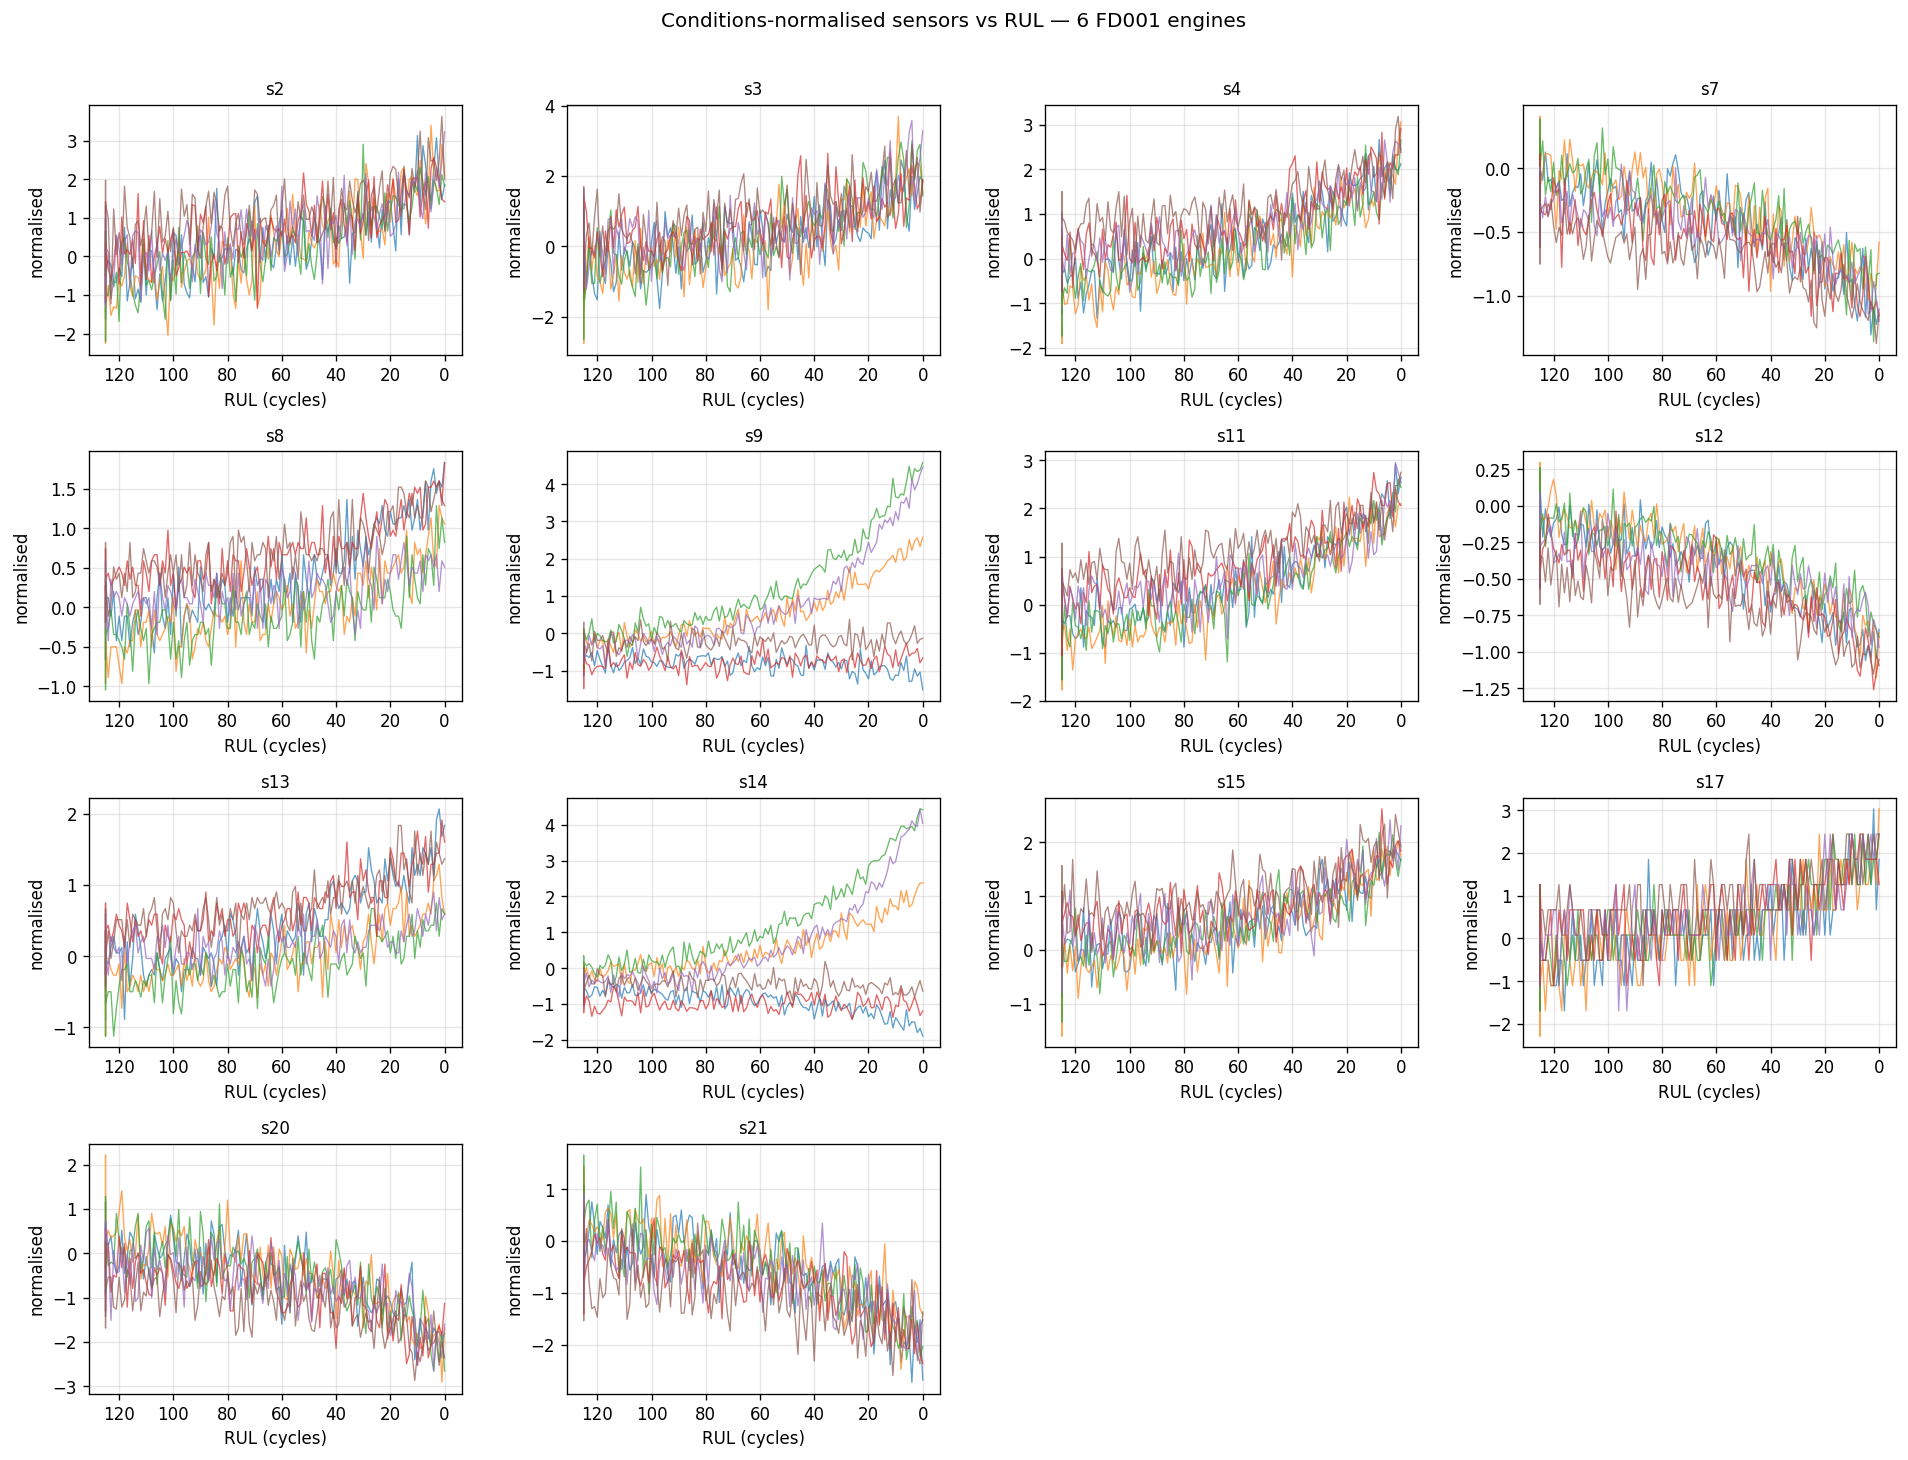

In [52]:
sample_eng = tr_f[tr_f["fd"] == 1]["unit_global"].unique()[:6]
sdf = tr_f[tr_f["unit_global"].isin(sample_eng)].copy()

ncols = 4
nrows = int(np.ceil(len(SCOLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for ax, sensor in zip(axes, SCOLS):
    for eng in sample_eng:
        edf = sdf[sdf["unit_global"] == eng].sort_values("rul", ascending=False)
        ax.plot(edf["rul"], edf[sensor], lw=0.8, alpha=0.7)
    ax.invert_xaxis()
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel("RUL (cycles)")
    ax.set_ylabel("normalised")
    ax.grid(alpha=0.3)

for ax in axes[len(SCOLS):]:
    ax.set_visible(False)

fig.suptitle("Conditions-normalised sensors vs RUL — 6 FD001 engines", y=1.01)
plt.tight_layout()
plt.savefig("sensor_vs_rul.png", bbox_inches="tight")
plt.show()

# Engineered Feature Plots

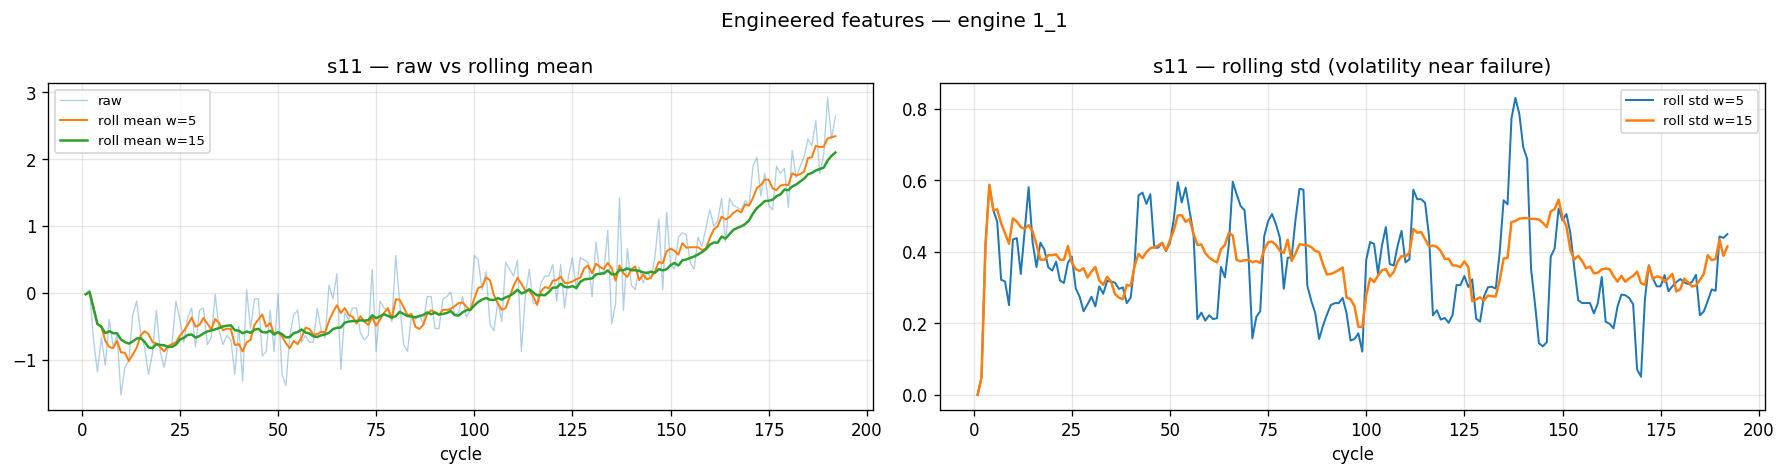

In [53]:
eng = sample_eng[0]
edf = tr_f[tr_f["unit_global"] == eng].sort_values("cycle")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ax = axes[0]
ax.plot(edf["cycle"], edf["s11"], alpha=0.35, lw=0.8, label="raw")
ax.plot(edf["cycle"], edf["s11_rm5"], lw=1.2, label="roll mean w=5")
ax.plot(edf["cycle"], edf["s11_rm15"], lw=1.5, label="roll mean w=15")
ax.set_title("s11 — raw vs rolling mean")
ax.set_xlabel("cycle")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(edf["cycle"], edf["s11_rs5"], lw=1.2, label="roll std w=5")
ax.plot(edf["cycle"], edf["s11_rs15"], lw=1.5, label="roll std w=15")
ax.set_title("s11 — rolling std (volatility near failure)")
ax.set_xlabel("cycle")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle(f"Engineered features — engine {eng}")
plt.tight_layout()
plt.savefig("engineered_features.png", bbox_inches="tight")
plt.show()

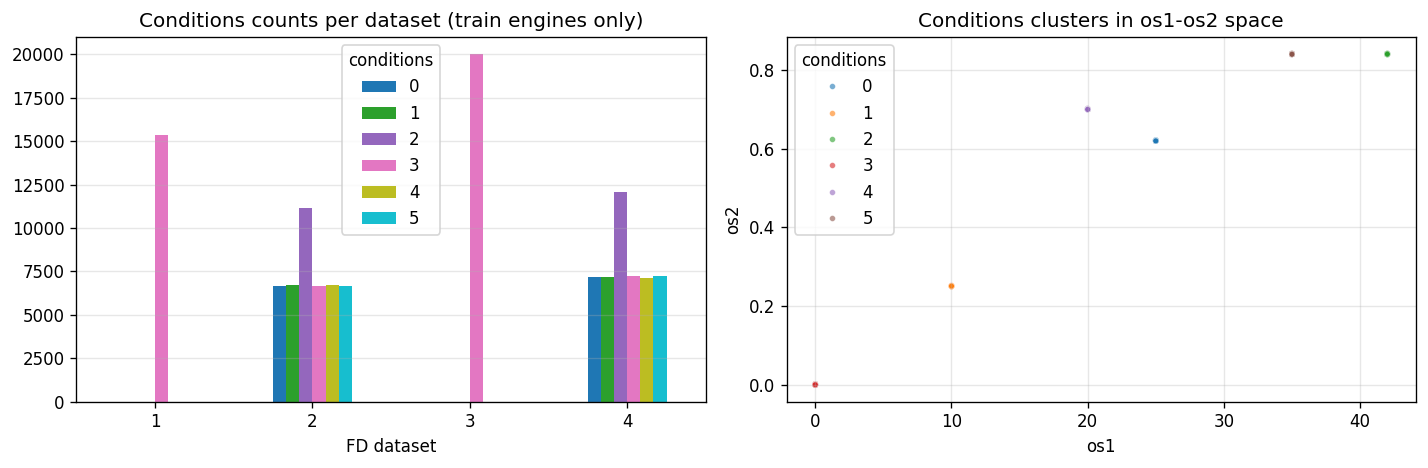

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tr_raw.groupby(["fd", "conditions"]).size().unstack().fillna(0).plot(
    kind="bar", ax=axes[0], colormap="tab10"
)
axes[0].set_title("Conditions counts per dataset (train engines only)")
axes[0].set_xlabel("FD dataset")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

sns.scatterplot(
    data=tr_raw.sample(4000, random_state=SEED),
    x="os1",
    y="os2",
    hue="conditions",
    palette="tab10",
    s=12,
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("Conditions clusters in os1-os2 space")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("conditions_clusters.png", bbox_inches="tight")
plt.show()

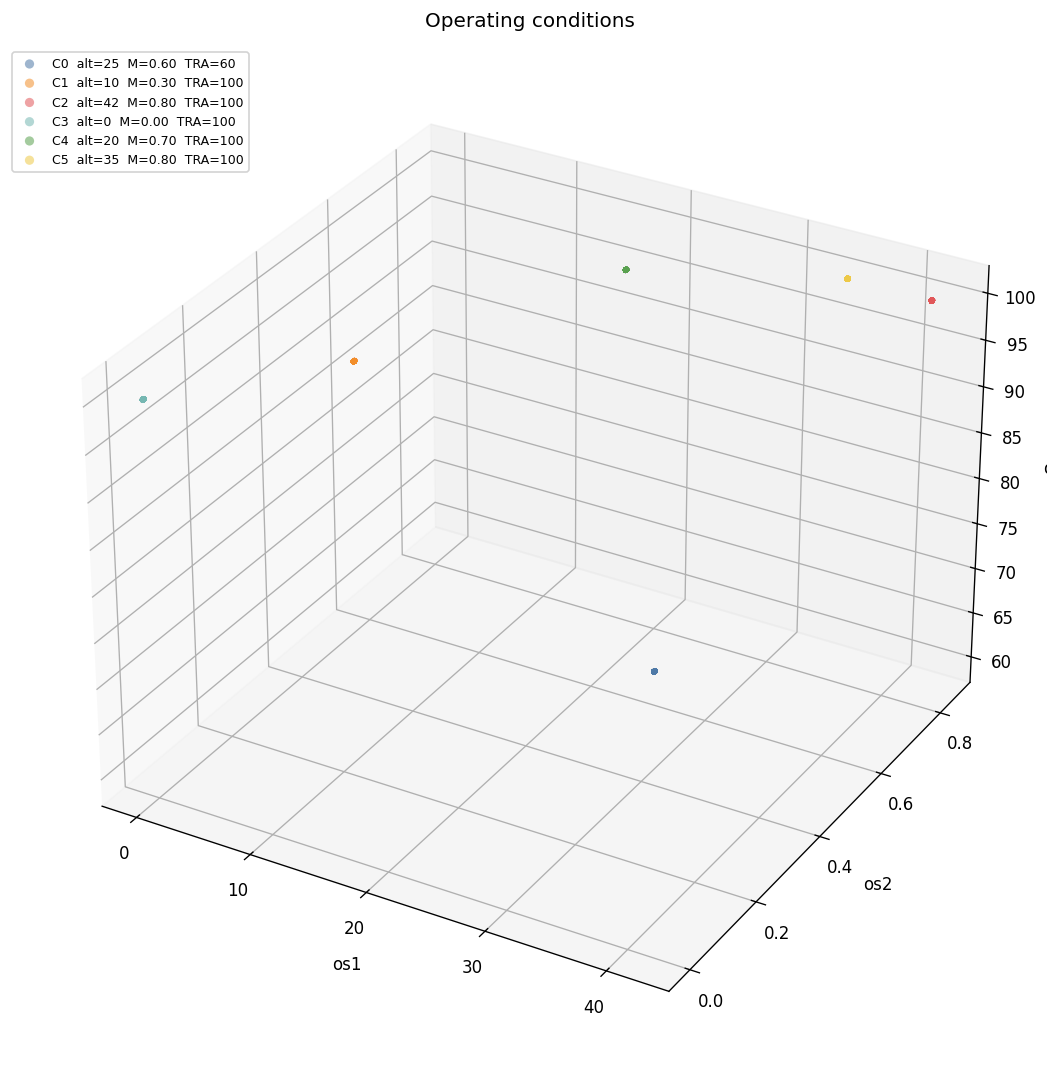

In [65]:
# readable label per centroid: altitude / Mach / TRA
centers = pd.DataFrame(km.cluster_centers_, columns=["os1", "os2", "os3"]).round(1)
cond_labels = {
    int(
        i
    ): f"C{i}  alt={centers.loc[i, 'os1']:.0f}  M={centers.loc[i, 'os2']:.2f}  TRA={centers.loc[i, 'os3']:.0f}"
    for i in range(6)
}

COLORS = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948"]

sample = tr_raw.sample(min(6000, len(tr_raw)), random_state=SEED)

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")

for cond in sorted(sample["conditions"].unique()):
    sub = sample[sample["conditions"] == cond]
    ax.scatter(
        sub["os1"],
        sub["os2"],
        sub["os3"],
        c=COLORS[cond],
        label=cond_labels[cond],
        s=12,
        alpha=0.55,
        edgecolors="none",
    )

# mark centroids
# cx = km.cluster_centers_
# ax.scatter(
#     cx[:, 0],
#     cx[:, 1],
#     cx[:, 2],  # type: ignore
#     c="black",
#     marker="X",
#     s=10,
#     zorder=5,
#     label="Centroids",
# )

ax.set_xlabel("os1", labelpad=8)
ax.set_ylabel("os2", labelpad=8)
ax.set_zlabel("os3", labelpad=8)
ax.set_title("Operating conditions", pad=12)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(-0.02, 1.0),
    fontsize=7.5,
    framealpha=0.85,
    markerscale=1.6,
)

plt.tight_layout()
plt.savefig("conditions_3d.png", bbox_inches="tight")
plt.show()

# Prediction Plots

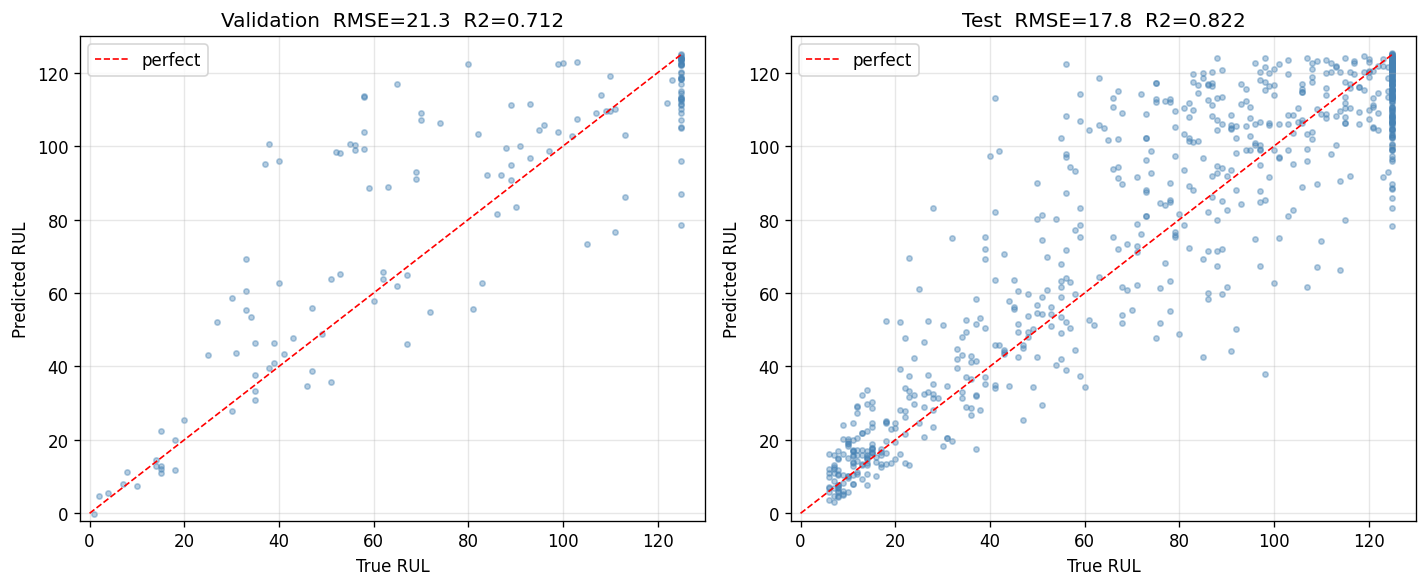

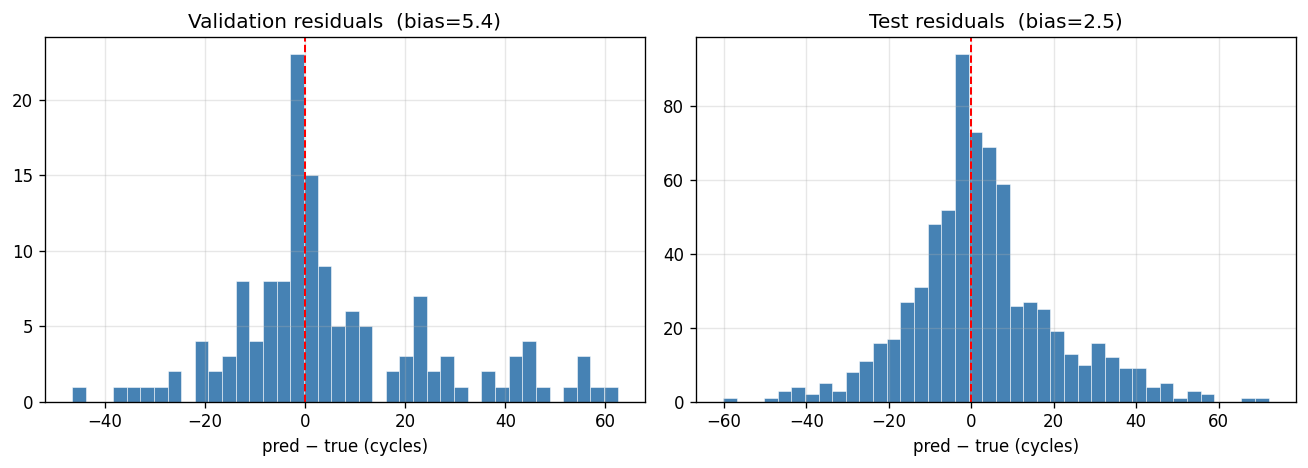

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, name in zip(axes, [res_va, res_te], ["Validation", "Test"]):
    ax.scatter(res["true"], res["pred"], s=10, alpha=0.4, color="steelblue")
    ax.plot([0, RUL_CAP], [0, RUL_CAP], "r--", lw=1, label="perfect")
    ax.set_xlim(-2, RUL_CAP + 5)
    ax.set_ylim(-2, RUL_CAP + 5)
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{name}  RMSE={res['rmse']:.1f}  R2={res['r2']:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pred_vs_true.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, name in zip(axes, [res_va, res_te], ["Validation", "Test"]):
    resid = res["pred"] - res["true"]
    ax.hist(resid, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red", lw=1.2, ls="--")
    ax.set_title(f"{name} residuals  (bias={resid.mean():.1f})")
    ax.set_xlabel("pred − true (cycles)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("residuals.png", bbox_inches="tight")
plt.show()

# Feature Importance & SHAP

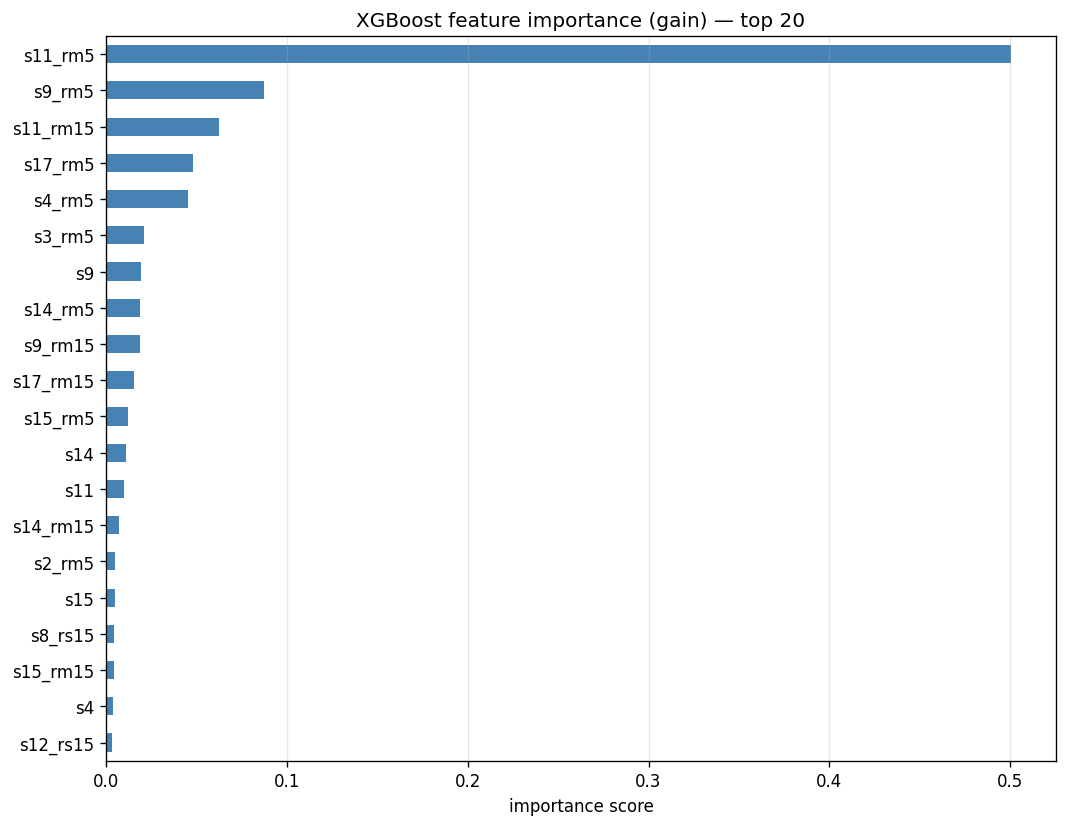

In [56]:
imp = pd.Series(model.feature_importances_, index=FCOLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
imp.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost feature importance (gain) — top 20")
ax.set_xlabel("importance score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

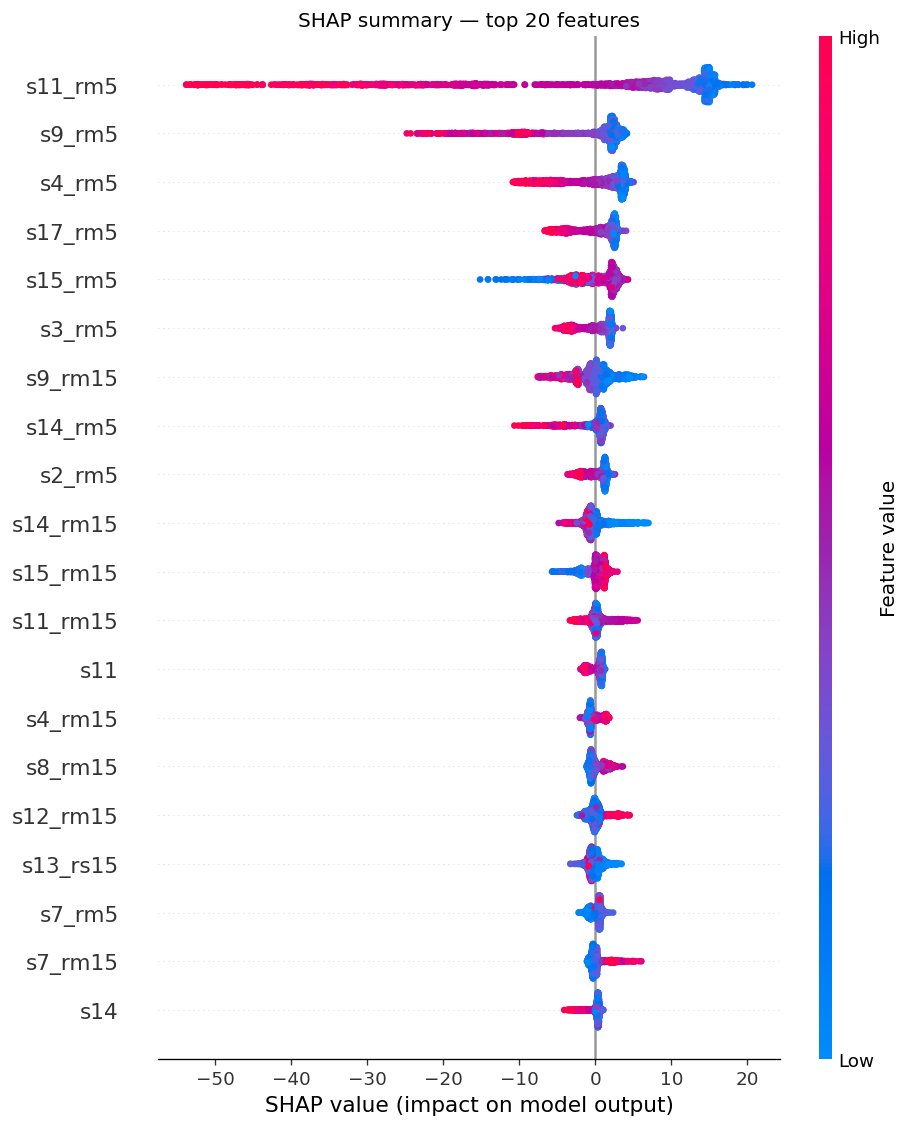

In [57]:
shap_sample = X_va_es.sample(min(2000, len(X_va_es)), random_state=SEED)
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, shap_sample, max_display=20, show=False)
plt.title("SHAP summary — top 20 features")
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()